# DSA 5102 - Programming Assignment 1


## Description

As the first homework of this course, you will apply the knowledge you have learned in the first lecture on `linear models` and simple extensions using `kernel` methods on some datasets. This is also a chance to learn to use `jupyter notebook` and basic `sklearn` functionalities. A basic introduction to installing and using `jupyter notebooks` is found [here](https://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook). You are strongly encouraged to use python 3 instead of python 2


The goals of this homework are
  * Learn basic data processing and machine learning using python
  * Reinforce knowledge on linear models and kernel methods
  * Prepare for the project in this course
  
Whenever you are stuck, you are encouraged to look at the jupyter notebook demonstration for the first lecture for some guidance. You should also learn to look at documentation of online libraries. For example, if you want to perform *kernel ridge regression* using `sklearn`, a quick google will land you on [this page](https://scikit-learn.org/stable/modules/kernel_ridge.html), where extensive description and examples are given.

## Instructions

Please complete each question below directly in this notebook. Note that you can write in the cells to describe what you are doing and any issues you face. If you are familiar, you can also format it using `markdown` as it is supported by `jupyter`. 

The grade given is based on the following
  1. Scientific correctness of your approach
  2. Clear documentation of your approach

## Dataset

We will work on the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy%2Befficiency) from the UCI Machine Learning Repository. The data describe 768 simulated residential building configurations. For this assignment, the goal is to predict **heating load** from eight building design properties:

1. `Relative_Compactness`
2. `Surface_Area`
3. `Wall_Area`
4. `Roof_Area`
5. `Overall_Height`
6. `Orientation`
7. `Glazing_Area`
8. `Glazing_Area_Distribution`

The original UCI dataset contains both heating-load and cooling-load responses. The supplied `energy_efficiency_heating.csv` retains the eight input variables and `Heating_Load` only, so the response is the last column. The dataset contains no missing values. Place the CSV file in the same folder as this notebook.

Dataset citation: Tsanas, A. & Xifara, A. (2012). *Energy Efficiency* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C51307](https://doi.org/10.24432/C51307). Licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv('/Users/taoyu/Library/Mobile Documents/com~apple~CloudDocs/dsml/DSA5102/data/energy_efficiency_heating.csv')
data.info

<bound method DataFrame.info of      Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                    0.98         514.5      294.0     110.25             7.0   
1                    0.98         514.5      294.0     110.25             7.0   
2                    0.98         514.5      294.0     110.25             7.0   
3                    0.98         514.5      294.0     110.25             7.0   
4                    0.90         563.5      318.5     122.50             7.0   
..                    ...           ...        ...        ...             ...   
763                  0.64         784.0      343.0     220.50             3.5   
764                  0.62         808.5      367.5     220.50             3.5   
765                  0.62         808.5      367.5     220.50             3.5   
766                  0.62         808.5      367.5     220.50             3.5   
767                  0.62         808.5      367.5     220.50             3.5

In [33]:
data.head()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


## Question 1 (2 points)

In this homework we are going to predict the last column values (`Heating_Load`) from design variables in the other columns. Choose 3 input properties and visualize each of their effects on the heating load. Plot your findings below. You may find the `seaborn` library examples in lecture 1 useful.


In [34]:
sns.set_style("whitegrid")

I selected `Surface_Area`, `Wall_Area`, and `Orientation` to examine their relationships with `Heating_Load`. This selection includes two numerical properties describing the geometry of a building and one categorical property describing its direction, allowing different types of relationships to be explored.

I expect buildings with a larger `Surface_Area` to generally require more heating because a greater external surface may increase heat exchange with the environment. Similarly, a larger `Wall_Area` may be associated with a higher heating load because more heat can potentially be transferred through the walls. I also expect `Orientation` to affect heating load because different orientations receive different amounts of solar radiation.

### Findings

#### 1. Surface Area

Surface area has a non-linear relationship with heating load. Despite fluctuations in the data, buildings with larger surface areas generally have lower heating loads than buildings with smaller surface areas. The observations are relatively scattered and do not follow a simple pattern because heating load is also affected by other building characteristics. In addition, surface area is related to some of the other input variables, such as wall area and roof area, which may also contribute to the irregular distribution.


#### 2. Orientation

The heating-load distributions are almost identical across the four orientationcategories. Their medians, interquartile ranges, and overall ranges are very similar.Therefore, orientation does not appear to have a strong individual effect on heatingload in this dataset.


#### 3. Wall Area

Wall area has a non-linear relationship with heating load. Despite fluctuations in the data, buildings with smaller wall areas generally have lower heating loads than buildings with larger wall areas. The observations are relatively scattered and do not follow a simple pattern because heating load is also affected by other building characteristics. In addition, wall area is related to other input variables, especially surface area and roof area, which may also contribute to the irregular distribution.

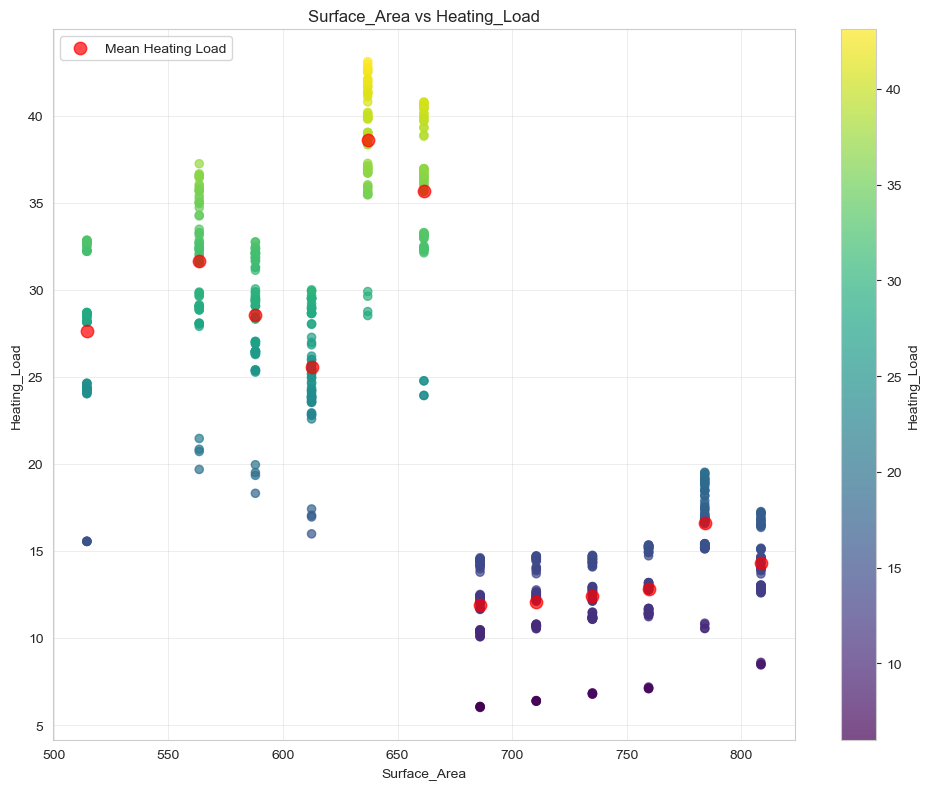

In [35]:
plt.figure(figsize=(10, 8))

surface_mean = (data.groupby('Surface_Area', as_index = False)['Heating_Load'].mean())

points = plt.scatter(
    x = data['Surface_Area'],
    y = data['Heating_Load'],
    c = data['Heating_Load'],
    cmap = 'viridis',
    s = 35,
    alpha = 0.7
)

plt.scatter(
    x = surface_mean['Surface_Area'],
    y = surface_mean['Heating_Load'],
    s = 80,
    alpha = 0.7,
    color = 'red',
    label = 'Mean Heating Load',
)

colorbar = plt.colorbar(points)
colorbar.set_label('Heating_Load')

plt.title('Surface_Area vs Heating_Load')
plt.xlabel('Surface_Area')
plt.ylabel('Heating_Load')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

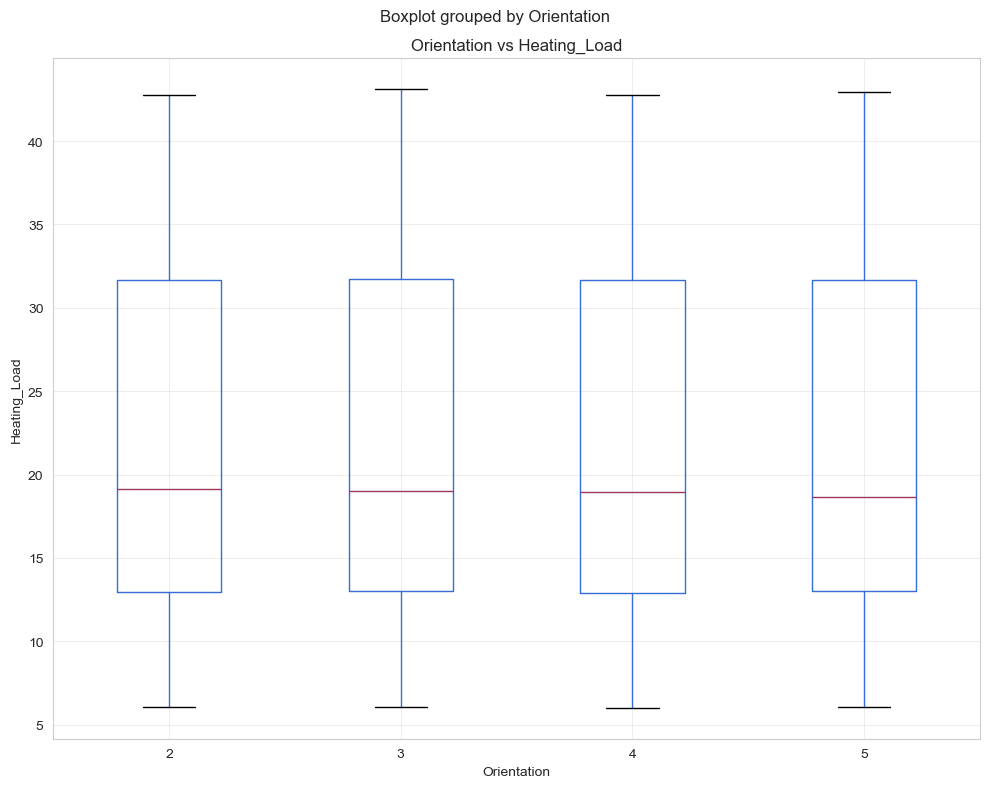

In [36]:
# If use scatter picture, it will only form 4 vertical lines because Orientation is divided into four categories, not actual continuous values. In this case, a boxplot is more appropriate.

data.boxplot(
    column='Heating_Load',
    by='Orientation',
    figsize=(10, 8)
)

plt.title('Orientation vs Heating_Load')
plt.xlabel('Orientation')
plt.ylabel('Heating_Load')
plt.tight_layout()
plt.show()

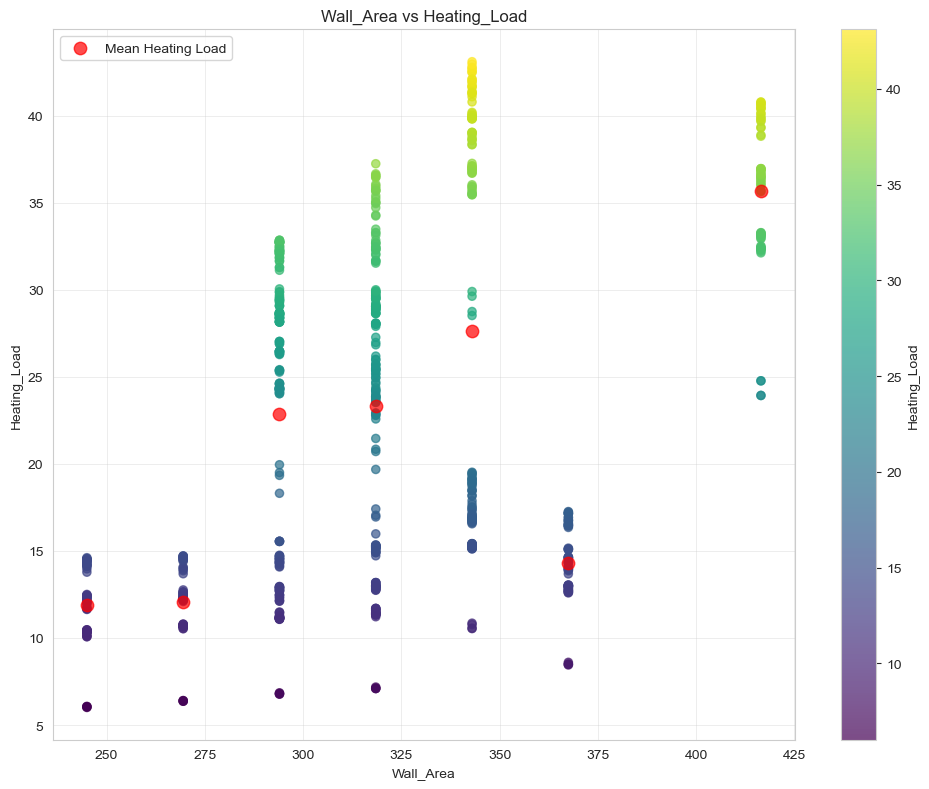

In [37]:
plt.figure(figsize=(10, 8))

wall_mean = (data.groupby('Wall_Area', as_index = False)['Heating_Load'].mean())

points = plt.scatter(
    x=data['Wall_Area'],
    y=data['Heating_Load'],
    c=data['Heating_Load'],
    cmap='viridis',
    s=35,
    alpha=0.7
)

plt.scatter(
    x = wall_mean['Wall_Area'],
    y = wall_mean['Heating_Load'],
    s = 80,
    alpha = 0.7,
    color = 'red',
    label = 'Mean Heating Load',
)

colorbar = plt.colorbar(points)
colorbar.set_label('Heating_Load')

plt.title('Wall_Area vs Heating_Load')
plt.xlabel('Wall_Area')
plt.ylabel('Heating_Load')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Question 2 (4 points)

Perform linear regression using all the input variables on this dataset to predict the heating load. Carefully evaluate your regression model using appropriate metrics and datasets.


MSE, scaled RMSE, and R^2 are used to evaluate different aspects of the model. MSE measures the squared prediction error and is sensitive to large errors. Scaled RMSE shows the size of the prediction error relative to the scale of the true values. R^2 shows how much better the model performs than simply predicting the average heating load.

In [38]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def rmse_scaled(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    scale = np.sqrt(np.mean(y_true**2))
    return rmse/scale

In [39]:
# Orientation and Glazing_Area_Distribution are categorical variables, so their numerical codes should not be treated as continuous quantities by linear regression. One-hot encoding converts each category into binary 0/1 features that the model can process without assuming a numerical order or equal distance between categories.
categorical_inputs = ['Orientation', 'Glazing_Area_Distribution']
data = pd.get_dummies(data, columns = categorical_inputs, drop_first = True, dtype = float)

data.head(10)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Glazing_Area,Heating_Load,Orientation_3,Orientation_4,Orientation_5,Glazing_Area_Distribution_1,Glazing_Area_Distribution_2,Glazing_Area_Distribution_3,Glazing_Area_Distribution_4,Glazing_Area_Distribution_5
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.90,563.5,318.5,122.50,7.0,0.0,21.46,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.90,563.5,318.5,122.50,7.0,0.0,20.71,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.90,563.5,318.5,122.50,7.0,0.0,19.68,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,0.86,588.0,294.0,147.00,7.0,0.0,19.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.86,588.0,294.0,147.00,7.0,0.0,19.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
dataset_train, dataset_test = train_test_split(data, test_size = 0.2, random_state = 48)
outputs = 'Heating_Load'

x_train = dataset_train.drop(columns = outputs)
x_test = dataset_test.drop(columns = outputs)

y_train = dataset_train[outputs]
y_test = dataset_test[outputs]

In [41]:
regressor = LinearRegression()

regressor.fit(
    X = x_train,
    y = y_train,
)
y_hat_train = regressor.predict(x_train)
y_hat_test = regressor.predict(x_test)

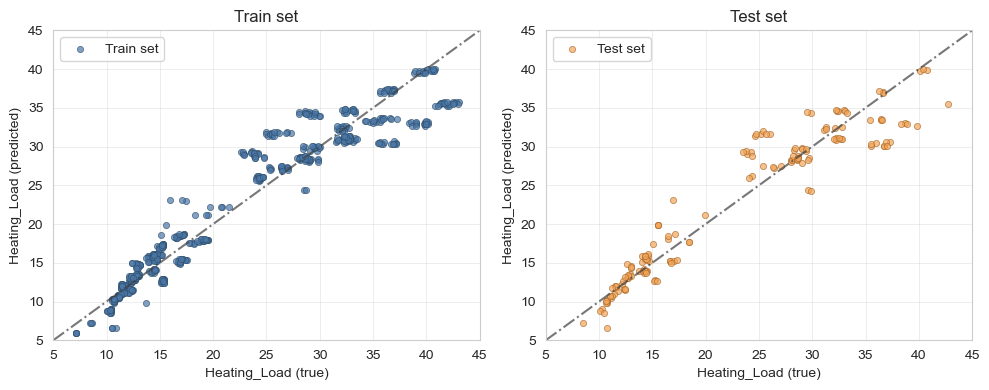

In [42]:
# To improve the visual presentation of the figures, I used AI assistance to explore and select a visually pleasing colour combination.
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].scatter(
    y_train,
    y_hat_train,
    s = 20,
    alpha = 0.7,
    color = '#4C78A8',
    edgecolor='#2F506E',
    linewidth=0.6,
    label = 'Train set'
)

ax[1].scatter(
    y_test,
    y_hat_test,
    s = 20,
    alpha = 0.7,
    color = '#F2A65A',
    edgecolor='#A96728',
    linewidth=0.6,
    label = 'Test set'
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predicted)')
    a.set_xlim(5, 45)
    a.set_ylim(5, 45)
    a.plot(
        a.get_xlim(),
        a.get_ylim(),
        ls = '-.',
        c = '#3D3D3D',
        alpha = 0.7,
    )
    a.legend()

ax[0].set_title('Train set')
ax[1].set_title('Test set')

fig.tight_layout()
plt.show()

In [43]:
mse_train = mean_squared_error(y_train, y_hat_train)
mse_test = mean_squared_error(y_test, y_hat_test)

scaled_rmse_train = rmse_scaled(y_train, y_hat_train)
scaled_rmse_test = rmse_scaled(y_test, y_hat_test)

r2_train = r2_score(y_train, y_hat_train)
r2_test = r2_score(y_test, y_hat_test)

evaluation = pd.DataFrame({
    'MSE': [mse_train, mse_test],
    'Scaled RMSE': [scaled_rmse_train, scaled_rmse_test],
    'R2': [r2_train, r2_test],},
    index=['Train', 'Test'])

evaluation

,MSE,Scaled RMSE,R2
Train,7.524921,0.112221,0.926933
Test,8.593590,0.119050,0.910830


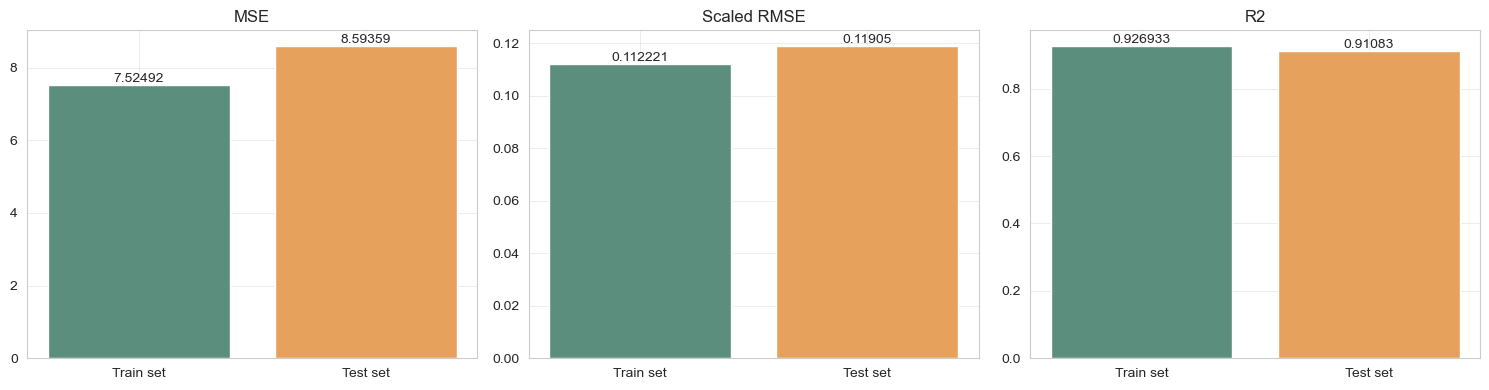

In [44]:
fig, ax = plt.subplots(1, 3, figsize = (15, 4))

metrics = ['MSE', 'Scaled RMSE', 'R2']
colors = ['#5B8E7D', '#E6A15C']

for a, metric in zip(ax, metrics):
    bars = a.bar(
        ['Train set', 'Test set'],
        evaluation[metric],
        color = colors
    )

    a.bar_label(bars)

    a.set_title(metric)

fig.tight_layout()
plt.show()

The linear regression model performs well on both the training and test sets. The test MSE is slightly higher than the training MSE, increasing from 7.525 to 8.594. Similarly, the scaled RMSE increases only slightly from 0.112 to 0.119. The test R^2 is 0.911.

The model performs well on both the training and test sets, and their evaluation metrics are very similar. This suggests that the model does not show clear signs of overfitting and can generalize consistently to unseen data.

## Question 3 (4 points)

Now, instead of linear regression, apply kernel ridge regression (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)) with 3 kernels:
1. Linear kernel
2. Polynomial kernel with degree 3
3. RBF (Gaussian) kernel

Quantify the performance improvement (if any) with respect to the linear case, and also the other kernels. What do you observe? Which would you choose?

*Hint: For the RBF kernel, should you do something to the inputs first? Why?*

---

Note: we have not gone through cross validation and hyper-parameter tuning yet, so you are not expected to do this here -- although you are free to do it if you know how.


In [45]:
from sklearn.kernel_ridge import KernelRidge

In [46]:
# Linear kernel
kr_linear = KernelRidge(kernel = 'linear') # default alpha = 1
kr_linear.fit(x_train, y_train)

y_hat_kr_linear_train = kr_linear.predict(x_train)
y_hat_kr_linear_test = kr_linear.predict(x_test)

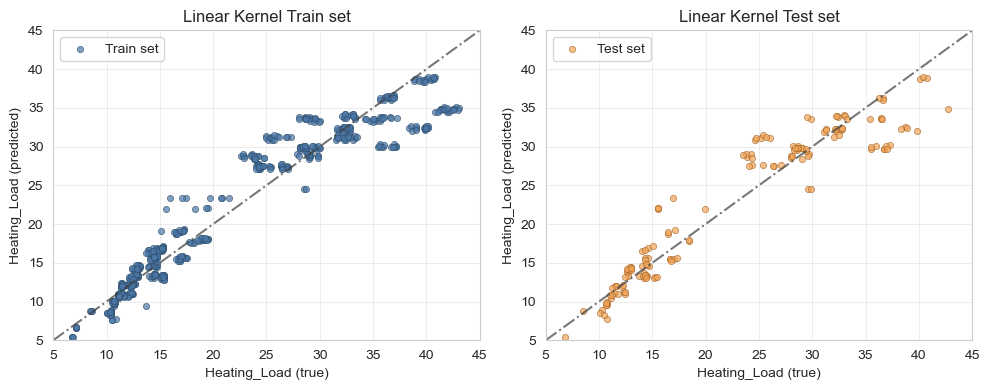

In [47]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].scatter(
    y_train,
    y_hat_kr_linear_train,
    s = 20,
    alpha = 0.7,
    color = '#4C78A8',
    edgecolor='#2F506E',
    linewidth=0.6,
    label = 'Train set'
)

ax[1].scatter(
    y_test,
    y_hat_kr_linear_test,
    s = 20,
    alpha = 0.7,
    color = '#F2A65A',
    edgecolor='#A96728',
    linewidth=0.6,
    label = 'Test set'
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predicted)')
    a.set_xlim(5, 45)
    a.set_ylim(5, 45)
    a.plot(
        a.get_xlim(),
        a.get_ylim(),
        ls = '-.',
        c = '#3D3D3D',
        alpha = 0.7,
    )
    a.legend()

ax[0].set_title('Linear Kernel Train set')
ax[1].set_title('Linear Kernel Test set')


fig.tight_layout()
plt.show()

In [48]:
# Polynomial kernel
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # get the mean and std from train set and standardize  the data
x_test_scaled = scaler.transform(x_test) # use the mean and std get above to standardize  the data
# Fitting the degree-3 polynomial kernel to the unscaled inputs initially produced a singular-matrix warning because the large differences in feature scales made the kernel matrix numerically unstable. I therefore standardized the inputs using the training-set statistics and applied the same transformation to the test set. This placed the features on comparable scales, improved numerical stability, and removed the warning.

kr_polynomial = KernelRidge(kernel = 'polynomial', degree = 3)
kr_polynomial.fit(x_train_scaled, y_train)

y_hat_kr_polynomial_train = kr_polynomial.predict(x_train_scaled)
y_hat_kr_polynomial_test = kr_polynomial.predict(x_test_scaled)

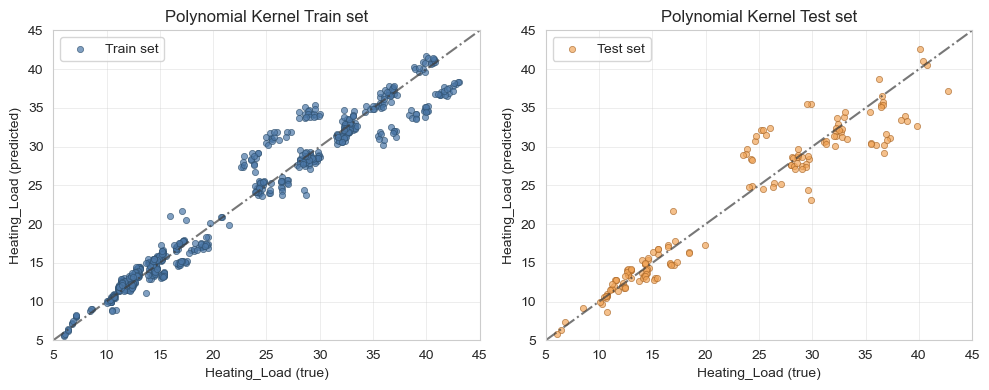

In [50]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].scatter(
    y_train,
    y_hat_kr_polynomial_train,
    s = 20,
    alpha = 0.7,
    color = '#4C78A8',
    edgecolor='#2F506E',
    linewidth=0.6,
    label = 'Train set'
)

ax[1].scatter(
    y_test,
    y_hat_kr_polynomial_test,
    s = 20,
    alpha = 0.7,
    color = '#F2A65A',
    edgecolor='#A96728',
    linewidth=0.6,
    label = 'Test set'
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predicted)')
    a.set_xlim(5, 45)
    a.set_ylim(5, 45)
    a.plot(
        a.get_xlim(),
        a.get_ylim(),
        ls = '-.',
        c = '#3D3D3D',
        alpha = 0.7,
    )
    a.legend()

ax[0].set_title('Polynomial Kernel Train set')
ax[1].set_title('Polynomial Kernel Test set')


fig.tight_layout()
plt.show()

In [ ]:
# RBF kernel


In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].scatter(
    y_train,
    y_hat_kr_polynomial_train,
    s = 20,
    alpha = 0.7,
    color = '#4C78A8',
    edgecolor='#2F506E',
    linewidth=0.6,
    label = 'Train set'
)

ax[1].scatter(
    y_test,
    y_hat_kr_polynomial_test,
    s = 20,
    alpha = 0.7,
    color = '#F2A65A',
    edgecolor='#A96728',
    linewidth=0.6,
    label = 'Test set'
)

for a in ax:
    a.set_xlabel(f'{outputs} (true)')
    a.set_ylabel(f'{outputs} (predicted)')
    a.set_xlim(5, 45)
    a.set_ylim(5, 45)
    a.plot(
        a.get_xlim(),
        a.get_ylim(),
        ls = '-.',
        c = '#3D3D3D',
        alpha = 0.7,
    )
    a.legend()

ax[0].set_title('RBF Kernel Train set')
ax[1].set_title('RBF Kernel Test set')


fig.tight_layout()
plt.show()